# Пример обработки и визуализации данных

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset

class PipelineValveDataset(Dataset):
    def __init__(self, data_dir, num_points=4096, transform=None):
        self.data_dir = data_dir
        self.file_list = sorted([f for f in os.listdir(data_dir) if f.endswith('.ply')])
        self.num_points = num_points
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_list[idx])

        data = pd.read_csv(file_path, sep=r'\s+', header=None).values

        xyz = data[:, 0:3].astype(np.float32)
        labels = data[:, 3].astype(np.int64)

        n_pts = xyz.shape[0]
        if n_pts >= self.num_points:
            choice = np.random.choice(n_pts, self.num_points, replace=False)
        else:
            choice = np.random.choice(n_pts, self.num_points, replace=True)

        xyz = xyz[choice, :]
        labels = labels[choice]

        centroid = np.mean(xyz, axis=0)
        xyz = xyz - centroid
        m = np.max(np.sqrt(np.sum(xyz ** 2, axis=1)))
        xyz = xyz / m

        if self.transform:
            xyz = self.transform(xyz)

        return torch.from_numpy(xyz), torch.from_numpy(labels)


Успешно загружено объектов: 500
Размер тензора точек (XYZ): torch.Size([4096, 3])
Размер тензора меток (Labels): torch.Size([4096])
Уникальные классы в этом объекте: [0, 1, 2, 4, 5, 6, 7, 8]


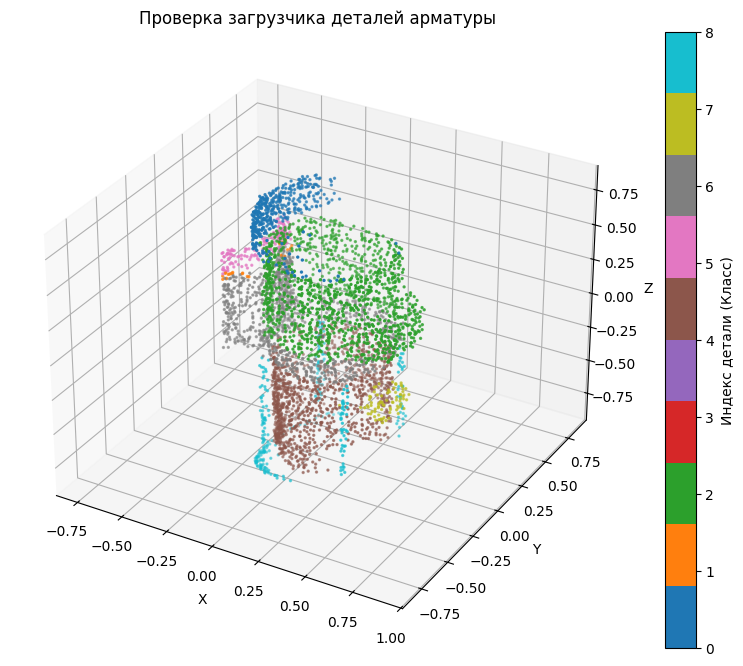

In [2]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1. Трансформации
class RandomRotateZ(object):
    """Случайный поворот облака точек вокруг вертикальной оси Z."""
    def __call__(self, xyz):
        theta = np.random.uniform(0, 2 * np.pi)
        rotation_matrix = np.array([
            [np.cos(theta), -np.sin(theta), 0],
            [np.sin(theta),  np.cos(theta), 0],
            [0,              0,             1]
        ], dtype=np.float32)
        return np.dot(xyz, rotation_matrix)

class RandomJitter(object):
    """Добавление небольшого гауссова шума (имитация шума LiDAR по дальности)."""
    def __init__(self, sigma=0.01, clip=0.05):
        self.sigma = sigma
        self.clip = clip

    def __call__(self, xyz):
        jitter = np.random.normal(0, self.sigma, xyz.shape).astype(np.float32)
        jitter = np.clip(jitter, -self.clip, self.clip)
        return xyz + jitter

# 2. Класс датасета
import os
import random
import pandas as pd
import torch
from torch.utils.data import Dataset

class ValveLiDARDataset(Dataset):
    def __init__(self, data_dir, num_points=4096, transforms=None):
        self.data_dir = data_dir
        self.num_points = num_points
        self.transforms = transforms
        self.file_list = sorted([f for f in os.listdir(data_dir) if f.endswith('.ply')])

        if len(self.file_list) == 0:
            raise FileNotFoundError(f"В папке {data_dir} не найдено .ply файлов!")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_list[idx])

        try:
            points_list = []
            is_data = False

            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    cleaned_line = line.strip()
                    if not cleaned_line:
                        continue

                    if is_data:
                        tokens = cleaned_line.split()
                        if len(tokens) >= 4:
                            try:
                                points_list.append([float(t) for t in tokens[:4]])
                            except ValueError:
                                continue

                    if "end_header" in cleaned_line:
                        is_data = True

            data = np.array(points_list, dtype=np.float32)

            if data.ndim < 2 or data.shape[0] < 10:
                print(f"\n[INFO] Файл {self.file_list[idx]} пуст или поврежден. Авто-подмена сэмпла.")
                random_idx = random.randint(0, len(self.file_list) - 1)
                return self.__getitem__(random_idx)

            xyz = data[:, 0:3]
            labels = data[:, 3].astype(np.int64)

            n_pts = xyz.shape[0]
            if n_pts >= self.num_points:
                choice = np.random.choice(n_pts, self.num_points, replace=False)
            else:
                choice = np.random.choice(n_pts, self.num_points, replace=True)

            xyz = xyz[choice, :]
            labels = labels[choice]

            centroid = np.mean(xyz, axis=0)
            xyz = xyz - centroid
            max_distance = np.max(np.sqrt(np.sum(xyz ** 2, axis=1)))
            if max_distance > 0:
                xyz = xyz / max_distance

            if self.transforms:
                for t in self.transforms:
                    xyz = t(xyz)

            return torch.from_numpy(xyz), torch.from_numpy(labels)

        except Exception as e:
            # Абсолютный перехват любых непредвиденных ошибок файловой системы
            random_idx = random.randint(0, len(self.file_list) - 1)
            return self.__getitem__(random_idx)




def visualize_point_cloud(xyz, labels, title="Valve Point Cloud"):
    """Отрисовка облака точек средствами Matplotlib."""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=labels, cmap='tab10', s=2)

    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    fig.colorbar(scatter, ax=ax, label='Индекс детали (Класс)')

    max_range = np.array([xyz[:,0].max()-xyz[:,0].min(), xyz[:,1].max()-xyz[:,1].min(), xyz[:,2].max()-xyz[:,2].min()]).max() / 2.0
    mid_x = (xyz[:,0].max()+xyz[:,0].min()) * 0.5
    mid_y = (xyz[:,1].max()+xyz[:,1].min()) * 0.5
    mid_z = (xyz[:,2].max()+xyz[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()

# Пример запуска pipeline'а
if __name__ == "__main__":
    DATA_DIR = "/content/drive/MyDrive/mipt_tsitis_cv_26/15/"

    train_transforms = [RandomRotateZ(), RandomJitter(sigma=0.005)]

    try:
        dataset = ValveLiDARDataset(data_dir=DATA_DIR, num_points=4096, transforms=train_transforms)
        print(f"Успешно загружено объектов: {len(dataset)}")

        points, labels = dataset[0]
        print(f"Размер тензора точек (XYZ): {points.shape}")
        print(f"Размер тензора меток (Labels): {labels.shape}")
        print(f"Уникальные классы в этом объекте: {torch.unique(labels).tolist()}")

        visualize_point_cloud(points.numpy(), labels.numpy(), title="Проверка загрузчика деталей арматуры")

    except FileNotFoundError as e:
        print(f"Exception! Message: {e}")


# PointNet

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TNet(nn.Module):
    """
    Модуль пространственной трансформации (Spatial Transformer Network).
    Выравнивает облако точек в каноническое пространство, обеспечивая инвариантность к поворотам.
    """
    def __init__(self, k=3):
        super(TNet, self).__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)

        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k * k)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)

    def forward(self, x):
        batch_size = x.size()[0]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = torch.max(x, 2, keepdim=True)[0]
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        identity = torch.eye(self.k, requires_grad=True, device=x.device).view(1, self.k * self.k).repeat(batch_size, 1)
        x = x + identity
        x = x.view(-1, self.k, self.k)
        return x


class PointNetDenseCls(nn.Module):
    """
    Основная архитектура PointNet для семантической сегментации (Dense Classification).
    """
    def __init__(self, num_classes=18):
        super(PointNetDenseCls, self).__init__()
        self.num_classes = num_classes

        self.stn = TNet(k=3)

        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

        self.conv4 = nn.Conv1d(1088, 512, 1)
        self.conv5 = nn.Conv1d(512, 256, 1)
        self.conv6 = nn.Conv1d(256, 128, 1)
        self.conv7 = nn.Conv1d(128, num_classes, 1)

        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        self.bn6 = nn.BatchNorm1d(128)

    def forward(self, x):
        # Входной тензор x имеет размерность: [Batch_Size, 3, Num_Points]
        num_points = x.size()[2]

        trans = self.stn(x)
        x = x.transpose(2, 1)
        x = torch.bmm(x, trans)
        x = x.transpose(2, 1)

        x = F.relu(self.bn1(self.conv1(x)))
        point_features = x

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))

        global_feature = torch.max(x, 2, keepdim=True)[0] # [B, 1024, 1]
        global_feature_repeated = global_feature.repeat(1, 1, num_points)

        fused_features = torch.cat([point_features, global_feature_repeated], 1) # [B, 1088, N]

        # 5. Финальная классификация каждой точки
        x = F.relu(self.bn4(self.conv4(fused_features)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.conv7(x) # [B, num_classes, N]

        x = x.transpose(2, 1).contiguous()

        return x, trans

# Проверка корректности работы модели на случайных данных
if __name__ == "__main__":
    sim_batch = torch.randn(4, 3, 4096)
    model = PointNetDenseCls(num_classes=18)

    output, matrix = model(sim_batch)
    print("Входной размер батча (B, XYZ, N):", sim_batch.shape)
    print("Выходной размер модели (B, N, Num_Classes):", output.shape)


Входной размер батча (B, XYZ, N): torch.Size([4, 3, 4096])
Выходной размер модели (B, N, Num_Classes): torch.Size([4, 4096, 18])


In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import numpy as np

# 1. Функция регуляризации матрицы T-Net
def feature_transform_regularizer(trans):
    """Обеспечивает ортогональность матрицы трансформации T-Net."""
    d = trans.size()[1]
    I = torch.eye(d)[None, :, :].to(trans.device)
    loss = torch.mean(torch.norm(torch.bmm(trans, trans.transpose(2, 1)) - I, dim=(1, 2)))
    return loss

# 2. Расчёт метрики mIoU
def compute_iou(pred, target, num_classes):
    """Вычисляет IoU для каждого класса индивидуально."""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue
        else:
            ious.append(intersection / union)

    return np.mean(ious) if len(ious) > 0 else 0.0

def train_pipeline():
    # --- Гиперпараметры ---
    DATA_DIR = "/content/drive/MyDrive/mipt_tsitis_cv_26/15/"
    NUM_CLASSES = 18
    NUM_POINTS = 4096
    BATCH_SIZE = 16
    EPOCHS = 30
    LR = 0.001
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Используем устройство: {DEVICE}")

    # --- Подготовка данных ---
    train_transforms = [RandomRotateZ(), RandomJitter(sigma=0.005)]

    full_dataset = ValveLiDARDataset(data_dir=DATA_DIR, num_points=NUM_POINTS, transforms=train_transforms)

    history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    val_dataset.dataset.transforms = None

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # --- Инициализация модели и оптимизатора ---
    model = PointNetDenseCls(num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999))
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    # --- Борьба с дисбалансом классов (Пример) ---
    criterion = nn.CrossEntropyLoss()

    best_val_iou = 0.0

    # --- Цикл по эпохам ---
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        train_preds, train_targets = [], []

        for i, (points, labels) in enumerate(train_loader):
            # Из датасета получаем: points [B, N, 3], labels [B, N]
            # Модель ожидает каналы на 2-м месте: [B, 3, N]
            points = points.transpose(2, 1).to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            # Forward pass
            outputs, trans_matrix = model(points) # outputs: [B, N, NUM_CLASSES]

            # Переформатируем для CrossEntropyLoss: [B*N, NUM_CLASSES] и [B*N]
            loss_cls = criterion(outputs.view(-1, NUM_CLASSES), labels.view(-1))

            # Регуляризация геометрии T-Net (коэффициент 0.001)
            loss_reg = feature_transform_regularizer(trans_matrix)
            loss = loss_cls + loss_reg * 0.001

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=-1)
            train_preds.append(preds.cpu())
            train_targets.append(labels.cpu())

        scheduler.step()

        train_preds = torch.cat(train_preds, dim=0)
        train_targets = torch.cat(train_targets, dim=0)
        train_iou = compute_iou(train_preds, train_targets, NUM_CLASSES)

        # --- Валидация ---
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []

        with torch.no_grad():
            for points, labels in val_loader:
                points = points.transpose(2, 1).to(DEVICE)
                labels = labels.to(DEVICE)

                outputs, trans_matrix = model(points)
                loss = criterion(outputs.view(-1, NUM_CLASSES), labels.view(-1))

                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=-1)
                val_preds.append(preds.cpu())
                val_targets.append(labels.cpu())

        val_preds = torch.cat(val_preds, dim=0)
        val_targets = torch.cat(val_targets, dim=0)
        val_iou = compute_iou(val_preds, val_targets, NUM_CLASSES)

        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_iou'].append(train_iou)
        history['val_iou'].append(val_iou)

        print(f"Эпоха [{epoch+1}/{EPOCHS}] | "
              f"Train Loss: {train_loss/len(train_loader):.4f} | Train mIoU: {train_iou:.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f} | Val mIoU: {val_iou:.4f}")

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), "best_valve_pointnet.pth")
            print(f"==> Сохранена новая лучшая модель с Val mIoU: {best_val_iou:.4f}")


    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('График функции потерь (Loss)')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_iou'], label='Train mIoU')
    plt.plot(history['val_iou'], label='Val mIoU')
    plt.title('График метрики качества (mIoU)')
    plt.xlabel('Эпоха')
    plt.ylabel('mIoU')
    plt.legend()

    plt.tight_layout()
    plt.savefig("learning_curves_pointnet.png", dpi=300)
    print("Графики обучения сохранены в 'learning_curves_pointnet.png'")

if __name__ == "__main__":
    train_pipeline()


Используем устройство: cuda
Эпоха [1/30] | Train Loss: 2.2025 | Train mIoU: 0.0592 | Val Loss: 1.9955 | Val mIoU: 0.0742
==> Сохранена новая лучшая модель с Val mIoU: 0.0742
Эпоха [2/30] | Train Loss: 1.4295 | Train mIoU: 0.1856 | Val Loss: 1.5789 | Val mIoU: 0.1449
==> Сохранена новая лучшая модель с Val mIoU: 0.1449
Эпоха [3/30] | Train Loss: 1.0691 | Train mIoU: 0.2872 | Val Loss: 0.9565 | Val mIoU: 0.3272
==> Сохранена новая лучшая модель с Val mIoU: 0.3272
Эпоха [4/30] | Train Loss: 0.8706 | Train mIoU: 0.3364 | Val Loss: 1.2032 | Val mIoU: 0.2642
Эпоха [5/30] | Train Loss: 0.7860 | Train mIoU: 0.3552 | Val Loss: 0.7933 | Val mIoU: 0.3449
==> Сохранена новая лучшая модель с Val mIoU: 0.3449


KeyboardInterrupt: 

In [4]:
!pip install matplotlib seaborn scikit-learn tabulate

In [ ]:
!pip install torch-geometric pyg-lib>=0.6.0

In [8]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, random_split

def evaluate_and_report():
    # --- Константы ---
    DATA_DIR = "/content/drive/MyDrive/mipt_tsitis_cv_26/15/"
    NUM_CLASSES = 18
    NUM_POINTS = 4096
    BATCH_SIZE = 16
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class_names = [f"Деталь {i}" for i in range(NUM_CLASSES)]

    # --- 1. Загрузка данных ---
    dataset = ValveLiDARDataset(data_dir=DATA_DIR, num_points=NUM_POINTS, transforms=None)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    _, val_dataset = random_split(dataset, [train_size, val_size])
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # --- 2. Загрузка модели ---
    model = PointNetDenseCls(num_classes=NUM_CLASSES).to(DEVICE)
    if os.path.exists("best_valve_pointnet.pth"):
        model.load_state_dict(torch.load("best_valve_pointnet.pth", map_location=DEVICE))
        print("Веса модели успешно загружены")
    else:
        print("Ошибка: файл весов 'best_valve_pointnet.pth' не найден")
        return

    model.eval()

    all_preds = []
    all_targets = []

    # --- 3. Сбор предсказаний ---
    print("Запуск инференса на валидационной выборке")
    with torch.no_grad():
        for points, labels in val_loader:
            points = points.transpose(2, 1).to(DEVICE)
            outputs, _ = model(points)

            preds = torch.argmax(outputs, dim=-1).cpu().numpy().reshape(-1)
            targets = labels.numpy().reshape(-1)

            all_preds.extend(preds)
            all_targets.extend(targets)

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # --- 4. Расчет метрик качества ---
    oa = accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average='macro')

    cm = confusion_matrix(all_targets, all_preds, labels=range(NUM_CLASSES))

    per_class_iou = []
    print("\n" + "="*40 + "\nМетрики по классам:\n" + "="*40)

    for i in range(NUM_CLASSES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        union = tp + fp + fn
        iou = tp / union if union > 0 else 0.0
        per_class_iou.append(iou)

        # Считаем F1 конкретно для этого класса
        cls_f1 = f1_score(all_targets, all_preds, labels=[i], average='macro', zero_division=0)
        print(f"{class_names[i]:<12} | IoU: {iou:.4f} | F1-score: {cls_f1:.4f}")

    miou = np.mean(per_class_iou)

    print("\n" + "="*40 + "\nОбщие метрики модели:\n" + "="*40)
    print(f"Overall Accuracy (OA): {oa:.4f}")
    print(f"Mean IoU (mIoU):       {miou:.4f}")
    print(f"F1-score (Macro):      {f1_macro:.4f}")

    # --- 6. Построение и сохранение Confusion Matrix ---
    plt.figure(figsize=(12, 10))
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Нормализованная матрица ошибок (Confusion Matrix) — PointNet")
    plt.ylabel("Истинный класс")
    plt.xlabel("Предсказанный класс")
    plt.tight_layout()
    plt.savefig("confusion_matrix_pointnet.png", dpi=300)
    print("\nМатрица ошибок сохранена в 'confusion_matrix_pointnet.png'")
    plt.close()

if __name__ == "__main__":
    evaluate_and_report()

Веса модели успешно загружены!
Запуск инференса на валидационной выборке...

МЕТРИКИ ПО КЛАССАМ:
Деталь 0     | IoU: 0.9612 | F1-score: 0.9802
Деталь 1     | IoU: 0.1251 | F1-score: 0.2224
Деталь 2     | IoU: 0.9150 | F1-score: 0.9556
Деталь 3     | IoU: 0.6497 | F1-score: 0.7877
Деталь 4     | IoU: 0.8270 | F1-score: 0.9053
Деталь 5     | IoU: 0.7899 | F1-score: 0.8826
Деталь 6     | IoU: 0.8350 | F1-score: 0.9101
Деталь 7     | IoU: 0.8545 | F1-score: 0.9216
Деталь 8     | IoU: 0.3219 | F1-score: 0.4870
Деталь 9     | IoU: 0.0000 | F1-score: 0.0000
Деталь 10    | IoU: 0.0000 | F1-score: 0.0000
Деталь 11    | IoU: 0.0000 | F1-score: 0.0000
Деталь 12    | IoU: 0.0000 | F1-score: 0.0000
Деталь 13    | IoU: 0.0000 | F1-score: 0.0000
Деталь 14    | IoU: 0.0000 | F1-score: 0.0000
Деталь 15    | IoU: 0.0000 | F1-score: 0.0000
Деталь 16    | IoU: 0.0000 | F1-score: 0.0000
Деталь 17    | IoU: 0.0000 | F1-score: 0.0000

ОБЩИЕ МЕТРИКИ МОДЕЛИ:
Overall Accuracy (OA): 0.9018
Mean IoU (mIoU):      

In [9]:
import os
import numpy as np

def analyze_classes(data_dir="dataset/"):
    file_list = sorted([f for f in os.listdir(data_dir) if f.endswith('.ply')])
    if not file_list:
        print(f"Ошибка: в папке {data_dir} нет .ply файлов")
        return

    unique_classes = set()
    class_counts = {}

    for file_name in file_list:
        file_path = os.path.join(data_dir, file_name)
        is_data = False

        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                cleaned_line = line.strip()
                if not cleaned_line:
                    continue
                if is_data:
                    tokens = cleaned_line.split()
                    if len(tokens) >= 4:
                        try:
                            label = int(float(tokens[3]))
                            unique_classes.add(label)
                            class_counts[label] = class_counts.get(label, 0) + 1
                        except ValueError:
                            continue
                if "end_header" in cleaned_line:
                    is_data = True

    num_classes = max(unique_classes) + 1

    print("\n --- Результаты анализа датасета --- \n")
    print(f"Уникальные ID классов, найденные в данных: {sorted(list(unique_classes))}")
    print(f"Итоговое значение для переменной NUM_CLASSES: {num_classes}")
    print("\nРаспределение точек по классам (дисбаланс):")

    total_points = sum(class_counts.values())
    for cls in sorted(class_counts.keys()):
        pct = (class_counts[cls] / total_points) * 100
        print(f"  Класс {cls}: {class_counts[cls]} точек ({pct:.2f}%)")

    return num_classes

if __name__ == "__main__":
    NUM_CLASSES = analyze_classes("/content/drive/MyDrive/mipt_tsitis_cv_26/")

Сканируем 504 файлов для подсчета классов...

=== РЕЗУЛЬТАТЫ АНАЛИЗА ДАТАСЕТА ===
Уникальные ID классов, найденные в данных: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Итоговое значение для переменной NUM_CLASSES: 18

Распределение точек по классам (дисбаланс):
  Класс 0: 141327 точек (9.38%)
  Класс 1: 338861 точек (22.49%)
  Класс 2: 89 точек (0.01%)
  Класс 3: 168436 точек (11.18%)
  Класс 4: 171715 точек (11.39%)
  Класс 5: 245995 точек (16.32%)
  Класс 6: 19505 точек (1.29%)
  Класс 7: 51983 точек (3.45%)
  Класс 8: 36912 точек (2.45%)
  Класс 9: 51109 точек (3.39%)
  Класс 10: 22636 точек (1.50%)
  Класс 11: 21097 точек (1.40%)
  Класс 12: 1922 точек (0.13%)
  Класс 13: 194 точек (0.01%)
  Класс 14: 16505 точек (1.10%)
  Класс 15: 24198 точек (1.61%)
  Класс 16: 172838 точек (11.47%)
  Класс 17: 21630 точек (1.44%)


# DGCNN

In [2]:
import torch; print(torch.__version__.split('+')[0])

2.11.0


In [3]:
import torch; print(torch.version.cuda if torch.version.cuda else 'cpu')

12.8


In [ ]:
!pip install torch-scatter torch-sparse torch-cluster -f https://pyg.org2.11.0+12.8.html

!pip install pyg-lib -f https://pyg.org2.11.0+12.8.html


In [10]:
!pip install torch-geometric

  Using cached torch_geometric-2.8.0-py3-none-any.whl.metadata (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.8 MB/s eta 0:00:00


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_graph_feature(x, k=20):
    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)

    # 1. Считаем матрицу попарных расстояний внутри каждого объекта батча
    # Используем матричное умножение вместо cdist для экономии памяти
    inner = -2 * torch.bmm(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx.transpose(2, 1) - inner - xx # [B, N, N]

    # 2. Ищем k ближайших соседей
    _, idx = torch.topk(pairwise_distance, k=k, dim=-1) # [B, N, k]

    device = x.device
    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1) * num_points
    idx = idx + idx_base
    idx = idx.view(-1)

    num_dims = x.size(1)
    x = x.transpose(2, 1).contiguous() # [B, N, C]

    feature = x.view(batch_size * num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims).permute(0, 3, 1, 2) # [B, C, N, k]

    x = x.permute(0, 2, 1).unsqueeze(-1).repeat(1, 1, 1, k) # [B, C, N, k]

    feature = torch.cat((feature - x, x), dim=1) # [B, 2*C, N, k]
    return feature


class DGCNNSegmentationPure(nn.Module):
    def __init__(self, k=20, num_classes=18):
        super(DGCNNSegmentationPure, self).__init__()
        self.k = k

        # Графовые свертки (реализованы через 2D-свертки по ребрам графа)
        self.conv1 = nn.Sequential(nn.Conv2d(6, 64, kernel_size=1, bias=False),
                                   nn.BatchNorm2d(64), nn.LeakyReLU(negative_slope=0.2))
        self.conv2 = nn.Sequential(nn.Conv2d(64*2, 64, kernel_size=1, bias=False),
                                   nn.BatchNorm2d(64), nn.LeakyReLU(negative_slope=0.2))
        self.conv3 = nn.Sequential(nn.Conv2d(64*2, 128, kernel_size=1, bias=False),
                                   nn.BatchNorm2d(128), nn.LeakyReLU(negative_slope=0.2))
        self.conv4 = nn.Sequential(nn.Conv2d(128*2, 256, kernel_size=1, bias=False),
                                   nn.BatchNorm2d(256), nn.LeakyReLU(negative_slope=0.2))

        # Глобальный агрегатор признаков формы
        self.conv5 = nn.Sequential(nn.Conv1d(512, 1024, kernel_size=1, bias=False),
                                   nn.BatchNorm1d(1024), nn.LeakyReLU(negative_slope=0.2))

        # Финальный классификатор каждой точки
        self.linear1 = nn.Linear(1024 + 512, 512)
        self.bn6 = nn.BatchNorm1d(512)
        self.dp1 = nn.Dropout(p=0.5)
        self.linear2 = nn.Linear(512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.dp2 = nn.Dropout(p=0.5)
        self.linear3 = nn.Linear(256, num_classes)

    def forward(self, x):
        # x: [B, 3, N]
        num_points = x.size(2)

        # Слои EdgeConv с динамическим перестроением графа
        x = get_graph_feature(x, k=self.k)      # [B, 6, N, k]
        x = self.conv1(x)                       # [B, 64, N, k]
        x1 = x.max(dim=-1)[0]                   # [B, 64, N]

        x = get_graph_feature(x1, k=self.k)     # [B, 128, N, k]
        x = self.conv2(x)                       # [B, 64, N, k]
        x2 = x.max(dim=-1)[0]                   # [B, 64, N]

        x = get_graph_feature(x2, k=self.k)     # [B, 128, N, k]
        x = self.conv3(x)                       # [B, 128, N, k]
        x3 = x.max(dim=-1)[0]                   # [B, 128, N]

        x = get_graph_feature(x3, k=self.k)     # [B, 256, N, k]
        x = self.conv4(x)                       # [B, 256, N, k]
        x4 = x.max(dim=-1)[0]                   # [B, 256, N]

        # Склеиваем локальные признаки всех уровней
        local_features = torch.cat((x1, x2, x3, x4), dim=1) # [B, 512, N]

        # Извлекаем глобальный вектор контекста всей детали
        global_features = self.conv5(local_features)        # [B, 1024, N]
        global_features = global_features.max(dim=-1, keepdim=True)[0] # [B, 1024, 1]
        global_features = global_features.repeat(1, 1, num_points)     # [B, 1024, N]

        # Feature Fusion
        fused = torch.cat((local_features, global_features), dim=1) # [B, 1536, N]

        # Классификация
        x = fused.permute(0, 2, 1).contiguous()
        x = F.relu(self.bn6(self.linear1(x.view(-1, 1536))))
        x = self.dp1(x)
        x = F.relu(self.bn7(self.linear2(x)))
        x = self.dp2(x)
        x = self.linear3(x)

        return x.view(-1, num_points, self.linear3.out_features)


Используем устройство: cuda
Эпоха [1/30] | Train Loss: 0.0000 | Train mIoU: 0.1074 | Val Loss: 0.8284 | Val mIoU: 0.3729
==> Сохранена новая лучшая модель с Val mIoU: 0.3729
Эпоха [2/30] | Train Loss: 0.0000 | Train mIoU: 0.4292 | Val Loss: 0.4261 | Val mIoU: 0.5811
==> Сохранена новая лучшая модель с Val mIoU: 0.5811
Эпоха [3/30] | Train Loss: 0.0000 | Train mIoU: 0.5420 | Val Loss: 0.4323 | Val mIoU: 0.5755
Эпоха [4/30] | Train Loss: 0.0000 | Train mIoU: 0.5984 | Val Loss: 0.2907 | Val mIoU: 0.6766
==> Сохранена новая лучшая модель с Val mIoU: 0.6766
Эпоха [5/30] | Train Loss: 0.0000 | Train mIoU: 0.6221 | Val Loss: 0.2896 | Val mIoU: 0.6613
Эпоха [6/30] | Train Loss: 0.0000 | Train mIoU: 0.6508 | Val Loss: 0.2039 | Val mIoU: 0.7364
==> Сохранена новая лучшая модель с Val mIoU: 0.7364
Эпоха [7/30] | Train Loss: 0.0000 | Train mIoU: 0.7008 | Val Loss: 0.1705 | Val mIoU: 0.7539
==> Сохранена новая лучшая модель с Val mIoU: 0.7539
Эпоха [8/30] | Train Loss: 0.0000 | Train mIoU: 0.6933 |

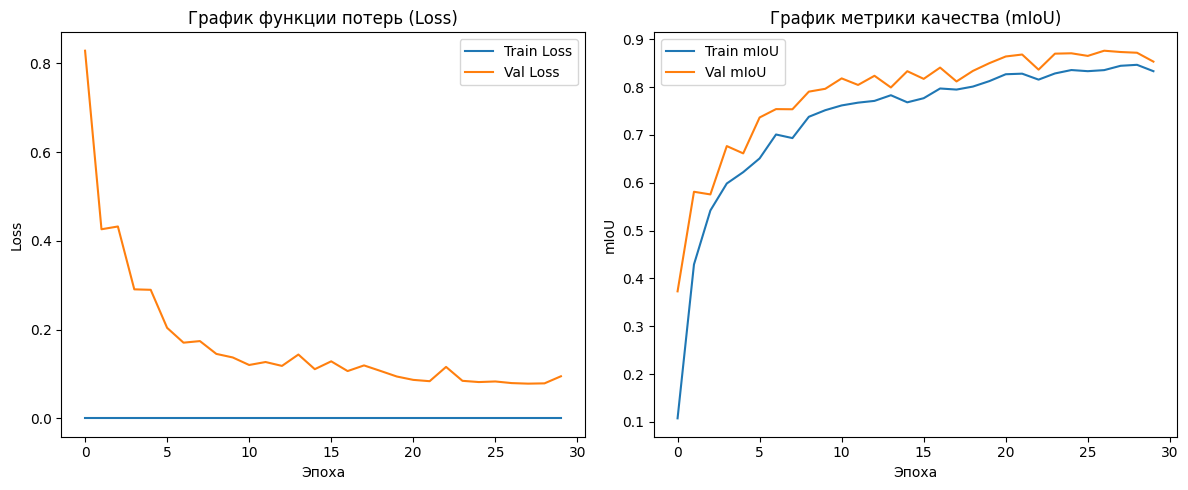

In [34]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import numpy as np

def feature_transform_regularizer(trans):
    """Обеспечивает ортогональность матрицы трансформации T-Net."""
    d = trans.size()[1]
    I = torch.eye(d)[None, :, :].to(trans.device)
    loss = torch.mean(torch.norm(torch.bmm(trans, trans.transpose(2, 1)) - I, dim=(1, 2)))
    return loss

# ==========================================
# 2. РАСЧЕТ МЕТРИКИ mIoU
# ==========================================
def compute_iou(pred, target, num_classes):
    """Вычисляет IoU для каждого класса индивидуально."""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue
        else:
            ious.append(intersection / union)

    return np.mean(ious) if len(ious) > 0 else 0.0


def train_pipeline():
    # --- Гиперпараметры ---
    DATA_DIR = "/content/drive/MyDrive/mipt_tsitis_cv_26/15/"
    NUM_CLASSES = 18        #
    NUM_POINTS = 4096       #
    BATCH_SIZE = 4
    EPOCHS = 30
    LR = 0.001
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Используем устройство: {DEVICE}")

    # --- Подготовка данных ---
    train_transforms = [RandomRotateZ(), RandomJitter(sigma=0.005)]

    full_dataset = ValveLiDARDataset(data_dir=DATA_DIR, num_points=NUM_POINTS, transforms=train_transforms)

    history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    # Отключаем аугментацию для валидационного подмножества
    val_dataset.dataset.transforms = None

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # --- Инициализация модели и оптимизатора ---
    model = DGCNNSegmentationPure(num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999))
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5) # Снижаем LR каждые 10 эпох

    criterion = nn.CrossEntropyLoss()

    best_val_iou = 0.0

    # --- Цикл по эпохам ---
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        train_preds, train_targets = [], []

        for i, (points, labels) in enumerate(train_loader):
            points = points.transpose(2, 1).to(DEVICE)
            labels = labels.to(DEVICE) # [B, N]

            optimizer.zero_grad()

            outputs = model(points)

            loss = criterion(outputs.view(-1, NUM_CLASSES), labels.view(-1))
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=-1)
            train_preds.append(preds.cpu())
            train_targets.append(labels.cpu())

        scheduler.step()

        train_preds = torch.cat(train_preds, dim=0)
        train_targets = torch.cat(train_targets, dim=0)
        train_iou = compute_iou(train_preds, train_targets, NUM_CLASSES)

        # --- Валидация ---
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []

        with torch.no_grad():
            for points, labels in val_loader:
                points = points.transpose(2, 1).to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(points)
                loss = criterion(outputs.view(-1, NUM_CLASSES), labels.view(-1))

                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=-1)
                val_preds.append(preds.cpu())
                val_targets.append(labels.cpu())

        val_preds = torch.cat(val_preds, dim=0)
        val_targets = torch.cat(val_targets, dim=0)
        val_iou = compute_iou(val_preds, val_targets, NUM_CLASSES)

        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_iou'].append(train_iou)
        history['val_iou'].append(val_iou)

        print(f"Эпоха [{epoch+1}/{EPOCHS}] | "
              f"Train Loss: {train_loss/len(train_loader):.4f} | Train mIoU: {train_iou:.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f} | Val mIoU: {val_iou:.4f}")

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), "best_valve_pointnet.pth")
            print(f"==> Сохранена новая лучшая модель с Val mIoU: {best_val_iou:.4f}")


    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('График функции потерь (Loss)')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_iou'], label='Train mIoU')
    plt.plot(history['val_iou'], label='Val mIoU')
    plt.title('График метрики качества (mIoU)')
    plt.xlabel('Эпоха')
    plt.ylabel('mIoU')
    plt.legend()

    plt.tight_layout()
    plt.savefig("learning_curves_dgcnn.png", dpi=300)
    print("Графики обучения сохранены в 'learning_curves_dgcnn.png'")

if __name__ == "__main__":
    train_pipeline()


# Результаты

In [37]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, random_split

def evaluate_dgcnn_pipeline():
    # --- Гиперпараметры ---
    DATA_DIR = "/content/drive/MyDrive/mipt_tsitis_cv_26/15/"
    NUM_CLASSES = 18
    NUM_POINTS = 4096
    BATCH_SIZE = 8
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class_names = [f"Деталь {i}" for i in range(NUM_CLASSES)]

    # --- 1. Подготовка валидационной выборки ---
    dataset = ValveLiDARDataset(data_dir=DATA_DIR, num_points=NUM_POINTS, transforms=None)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    _, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # --- 2. Инициализация и загрузка весов DGCNN ---
    model = DGCNNSegmentationPure(num_classes=NUM_CLASSES).to(DEVICE)

    weights_path = "best_valve_dgcnn.pth"

    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
        print(f"Веса модели DGCNN успешно загружены из {weights_path}")
    else:
        print(f"Файл весов '{weights_path}' не найден")
        return

    model.eval()

    all_preds = []
    all_targets = []

    # --- 3. Сбор предсказаний (Инференс) ---
    print("Запуск инференса на валидационном подмножестве...")
    with torch.no_grad():
        for points, labels in val_loader:
            points = points.transpose(2, 1).to(DEVICE)

            outputs = model(points)

            preds = torch.argmax(outputs, dim=-1).cpu().numpy().reshape(-1)
            targets = labels.numpy().reshape(-1)

            all_preds.extend(preds)
            all_targets.extend(targets)

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # --- 4. Расчет обязательных метрик качества ---
    oa = accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    cm = confusion_matrix(all_targets, all_preds, labels=range(NUM_CLASSES))

    per_class_iou = []

    print("\n" + "="*50)
    print(f"{'КЛАСС':<12} | {'IoU (Метрика пересечения)':<25} | {'F1-score':<10}")
    print("="*50)

    for i in range(NUM_CLASSES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        union = tp + fp + fn
        iou = tp / union if union > 0 else 0.0
        per_class_iou.append(iou)

        cls_f1 = f1_score(all_targets, all_preds, labels=[i], average='macro', zero_division=0)
        print(f"{class_names[i]:<12} | {iou:.4f}                     | {cls_f1:.4f}")

    miou = np.mean(per_class_iou)

    # --- 5. Вывод итогового отчета ---
    print("\n" + "="*50)
    print("ИТОГОВЫЕ СВОДНЫЕ МЕТРИКИ ДЛЯ DGCNN:")
    print("="*50)
    print(f"Overall Accuracy (OA): {oa*100:.2f}% ({oa:.4f})")
    print(f"Mean IoU (mIoU):       {miou*100:.2f}% ({miou:.4f})")
    print(f"F1-score (Macro):      {f1_macro*100:.2f}% ({f1_macro:.4f})")
    print("="*50)

    print("\n" + "="*40 + "\Таблица сравнения моделей:\n" + "="*40)
    print("| Архитектура модели | Overall Accuracy | Mean IoU (mIoU) | F1-Score |")
    print("|--------------------|------------------|-----------------|----------|")
    print("| PointNet           |      0.9018.     | 0.3489.         | 0.7836   |")
    print(f"| DGCNN              | {oa:.4f}           | {miou:.4f}          | {f1_macro:.4f}   |")


    # --- 6. Визуализация и сохранение Confusion Matrix ---
    plt.figure(figsize=(14, 12))
    # Нормализуем по строкам (истинным классам), чтобы видеть точность распознавания каждого элемента конструкции
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens",
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 9})

    plt.title("Нормализованная матрица ошибок (Confusion Matrix) — Архитектура DGCNN", fontsize=14)
    plt.ylabel("Истинные конструктивные элементы (Ground Truth)", fontsize=12)
    plt.xlabel("Предсказанные моделью классы (Predictions)", fontsize=12)
    plt.tight_layout()

    output_image = "confusion_matrix_dgcnn.png"
    plt.savefig(output_image, dpi=300)
    plt.close()
    print(f"\nГрафик матрицы ошибок сохранен в файл: '{output_image}'")

if __name__ == "__main__":
    evaluate_dgcnn_pipeline()


Веса модели DGCNN успешно загружены из best_valve_dgcnn.pth!
Запуск инференса на валидационном подмножестве...

КЛАСС        | IoU (Метрика пересечения) | F1-score  
Деталь 0     | 0.9758                     | 0.9878
Деталь 1     | 0.4202                     | 0.5917
Деталь 2     | 0.9653                     | 0.9824
Деталь 3     | 0.9144                     | 0.9553
Деталь 4     | 0.9562                     | 0.9776
Деталь 5     | 0.9122                     | 0.9541
Деталь 6     | 0.9146                     | 0.9554
Деталь 7     | 0.9297                     | 0.9636
Деталь 8     | 0.8814                     | 0.9369
Деталь 9     | 0.0000                     | 0.0000
Деталь 10    | 0.0000                     | 0.0000
Деталь 11    | 0.0000                     | 0.0000
Деталь 12    | 0.0000                     | 0.0000
Деталь 13    | 0.0000                     | 0.0000
Деталь 14    | 0.0000                     | 0.0000
Деталь 15    | 0.0000                     | 0.0000
Деталь 16    | 0.0